# Метод K ближайших соседей (KNN)

**Цель работы:** изучить работу KNeighborsClassifier для задач классификации.

**Содержание работы:**
1. Загрузка датасета «Ирисы», выбор двух признаков.
2. Минимаксная нормализация данных (MinMaxScaler).
3. Построение модели KNN (k=3), оценка качества.
4. Визуализация областей классификации.
5. Предсказание для нового наблюдения с визуализацией ближайших соседей.

## 1. Импорт библиотек

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

## 2. Загрузка и подготовка данных

In [2]:
iris = load_iris()
features = iris.data

data = pd.DataFrame(features, columns=iris.feature_names)
print('Первые 5 строк:')
display(data.head())

X = data.iloc[:, [0, 2]]  # Длина чашелистика и длина лепестка
y = iris.target
print(f'\nРазмер X: {X.shape}, y: {y.shape}')

Первые 5 строк:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2



Размер X: (150, 2), y: (150,)


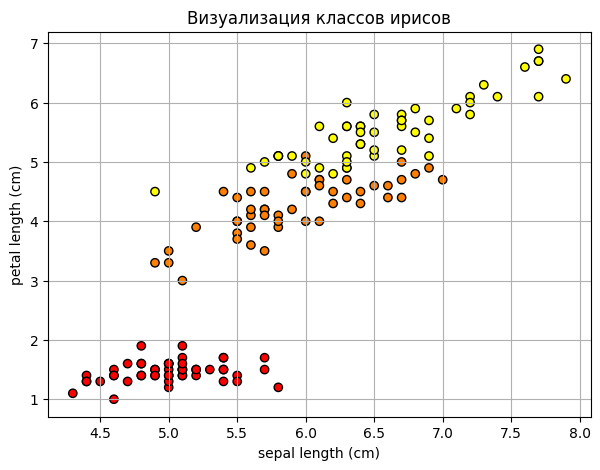

In [3]:
plt.figure(figsize=(7, 5))
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y, cmap='autumn', edgecolors='k')
plt.title('Визуализация классов ирисов')
plt.xlabel('sepal length (cm)')
plt.ylabel('petal length (cm)')
plt.grid(True)
plt.show()

## 3. Минимаксная нормализация

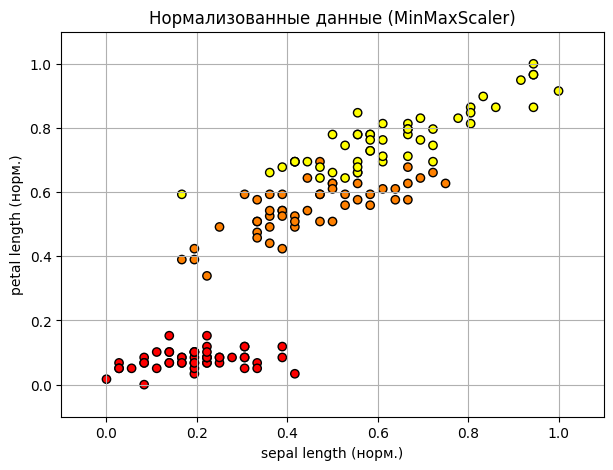

In [4]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

plt.figure(figsize=(7, 5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap='autumn', edgecolors='k')
plt.title('Нормализованные данные (MinMaxScaler)')
plt.xlabel('sepal length (норм.)')
plt.ylabel('petal length (норм.)')
plt.xlim(-0.1, 1.1)
plt.ylim(-0.1, 1.1)
plt.grid(True)
plt.show()

MinMaxScaler приводит все признаки к диапазону [0, 1]. Взаимное расположение точек не изменилось, но масштабы унифицированы — это критично для KNN.

## 4. Построение модели KNN (k=3)

In [5]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_scaled, y)

y_pred = knn.predict(X_scaled)
print(f'Accuracy: {accuracy_score(y, y_pred):.4f}')
print('\nОтчёт о классификации:')
print(classification_report(y, y_pred, target_names=iris.target_names))

Accuracy: 0.9600

Отчёт о классификации:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        50
  versicolor       0.94      0.94      0.94        50
   virginica       0.94      0.94      0.94        50

    accuracy                           0.96       150
   macro avg       0.96      0.96      0.96       150
weighted avg       0.96      0.96      0.96       150



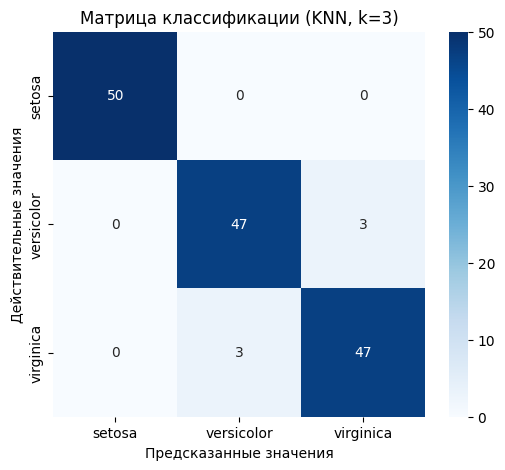

In [6]:
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.title('Матрица классификации (KNN, k=3)')
plt.ylabel('Действительные значения')
plt.xlabel('Предсказанные значения')
plt.show()

Модель правильно классифицирует ~96% объектов. Ошибки возникают только между versicolor и virginica.

## 5. Визуализация областей классификации

c:\Users\w1nore\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


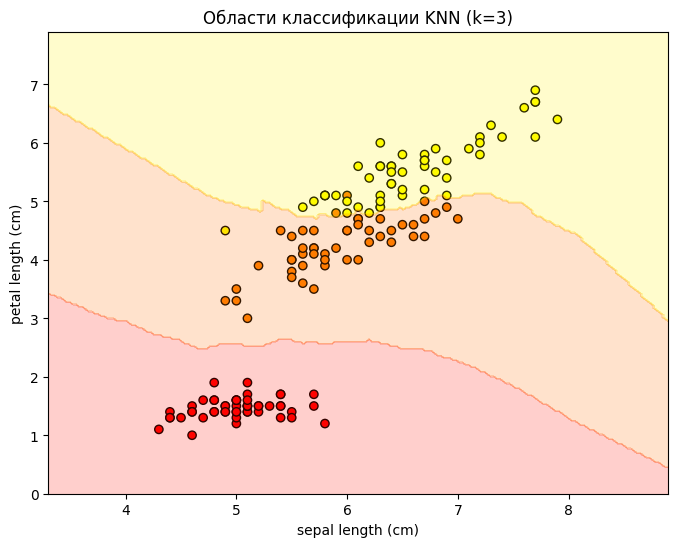

In [7]:
X0 = np.linspace(X.iloc[:, 0].min() - 1, X.iloc[:, 0].max() + 1, 200)
X1 = np.linspace(X.iloc[:, 1].min() - 1, X.iloc[:, 1].max() + 1, 200)
X0_grid, X1_grid = np.meshgrid(X0, X1)

XX = np.array([X0_grid.ravel(), X1_grid.ravel()]).T
XX_scaled = scaler.transform(XX)
Z = knn.predict(XX_scaled).reshape(X0_grid.shape)

plt.figure(figsize=(8, 6))
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y, cmap='autumn', edgecolors='k')
plt.contourf(X0_grid, X1_grid, Z, cmap='autumn', alpha=0.2)
plt.xlabel('sepal length (cm)')
plt.ylabel('petal length (cm)')
plt.title('Области классификации KNN (k=3)')
plt.show()

## 6. Новое наблюдение и ближайшие соседи

In [8]:
observation_new = [[5.5, 5]]
observation_new_scaled = scaler.transform(observation_new)

print(f'Предсказанный класс: {iris.target_names[knn.predict(observation_new_scaled)[0]]}')
print(f'Вероятности по классам: {knn.predict_proba(observation_new_scaled)[0]}')

distances, indices = knn.kneighbors(observation_new_scaled)
print(f'\nРасстояния до 3 ближайших соседей: {distances[0]}')
print(f'Индексы соседей: {indices[0]}')
print('Координаты соседей (нормализованные):')
for i, idx in enumerate(indices[0]):
    print(f'  Сосед {i+1}: X_scaled={X_scaled[idx]}, класс={iris.target_names[y[idx]]}')

Предсказанный класс: virginica
Вероятности по классам: [0. 0. 1.]

Расстояния до 3 ближайших соседей: [0.03254042 0.05555556 0.08503951]
Индексы соседей: [121 113 101]
Координаты соседей (нормализованные):
  Сосед 1: X_scaled=[0.36111111 0.66101695], класс=virginica
  Сосед 2: X_scaled=[0.38888889 0.6779661 ], класс=virginica
  Сосед 3: X_scaled=[0.41666667 0.69491525], класс=virginica


c:\Users\w1nore\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


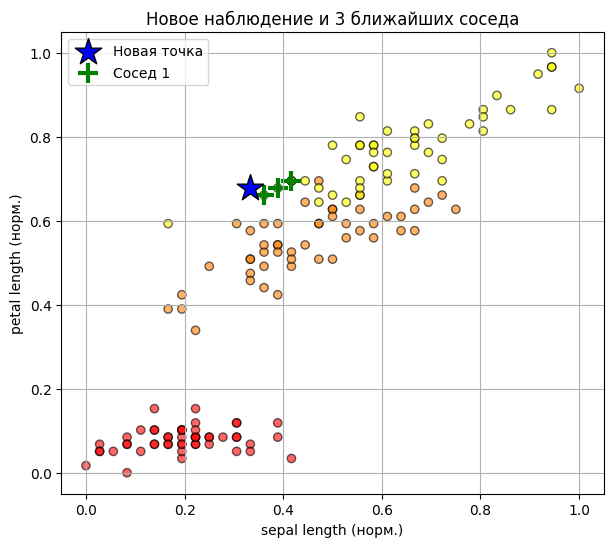

In [9]:
plt.figure(figsize=(7, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap='autumn', edgecolors='k', alpha=0.6)
plt.scatter(observation_new_scaled[0][0], observation_new_scaled[0][1],
            marker='*', s=400, color='blue', edgecolors='k', label='Новая точка', zorder=5)
for i, idx in enumerate(indices[0]):
    plt.scatter(X_scaled[idx][0], X_scaled[idx][1], marker='+', s=200,
                color='green', linewidth=3, label=f'Сосед {i+1}' if i == 0 else None)
plt.title('Новое наблюдение и 3 ближайших соседа')
plt.xlabel('sepal length (норм.)')
plt.ylabel('petal length (норм.)')
plt.legend()
plt.grid(True)
plt.show()

## Выводы

1. KNN (k=3) достигает accuracy ~96% на датасете ирисов с двумя признаками.
2. **Нормализация обязательна** для KNN — алгоритм основан на расстоянии между точками.
3. MinMaxScaler приводит признаки к [0, 1], сохраняя взаимное расположение точек.
4. Области классификации имеют характерную кусочно-линейную форму (Voronoi-диаграмма).
5. Метод `kneighbors()` позволяет находить ближайшие объекты обучающей выборки — это помогает интерпретировать предсказания.